# Clustering Analysis Notebook


Basic clustering analysis using the mean of all numeric features

In [32]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

raw_path = Path('agg_full_with_tsfresh.csv')
df = pd.read_csv(raw_path)
# Only select columns with numeric dtypes
numeric_cols = [c for c in df.columns if c not in ('order_date', 'coating_id') and pd.api.types.is_numeric_dtype(df[c])]
feature_matrix = df.groupby('coating_id')[numeric_cols].mean().reset_index()

X = feature_matrix.values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)
feature_matrix['cluster_label'] = labels
feature_matrix.head()

,coating_id,total_fill_rate,mean_fill_rate,median_fill_rate,min_fill_rate,max_fill_rate,std_fill_rate,total_chf,mean_chf,median_chf,...,num_product_families_w10_value__median,num_product_families_w10_value__mean,num_product_families_w10_value__length,num_product_families_w10_value__standard_deviation,num_product_families_w10_value__variance,num_product_families_w10_value__root_mean_square,num_product_families_w10_value__maximum,num_product_families_w10_value__absolute_maximum,num_product_families_w10_value__minimum,cluster_label
0,1,6.140,0.090,0.010,0.001,2.023,0.311,"4,448.970",70.635,20.913,...,1.977,1.804,10.000,0.434,0.278,1.886,2.087,2.087,0.780,0
1,2,1.504,0.052,0.013,0.003,0.638,0.130,"1,073.316",40.076,16.585,...,2.019,2.013,10.000,0.715,0.561,2.154,2.952,2.952,0.734,0
2,3,30.223,0.082,0.023,0.002,2.890,0.255,"45,916.234",120.557,45.213,...,1.993,1.911,10.000,0.376,0.247,1.979,2.369,2.369,1.112,2
3,4,0.763,0.059,0.034,0.012,0.268,0.077,"2,493.236",217.161,165.843,...,0.971,0.867,10.000,0.430,0.211,0.984,1.533,1.533,0.126,3
4,5,1.571,0.079,0.045,0.010,0.353,0.093,"3,679.958",178.365,111.769,...,0.990,0.951,10.000,0.265,0.101,1.005,1.279,1.279,0.450,3


In [ ]:
import pandas as pd

# 1) Load file
df = feature_matrix.copy()  

# 2) Tell the code which columns are which
cluster_col = "cluster_label"         # the column created by K-means / hierarchical
metric_col  = "total_fill_rate"  

# 3) Build the summary table
summary = (
    df
    .groupby(cluster_col)# [metric_col]     # group rows by cluster ID
    .agg(                                 # compute several statistics at once
        n_ids=('coating_id', 'count'),
        mean=(metric_col, 'mean'),
        median=(metric_col, 'median'),
        std=(metric_col, 'std'),
        coating_ids=('coating_id', lambda x: ", ".join(x.astype(str)))
    )
    .round(2)                             # keep numbers readable (2 decimals)
    .reset_index()                        # turn cluster labels back into a column
)

# 4) Show the result
print(summary)


   cluster_label  n_ids   mean  median   std  \
0              0     13  4.820   5.290 2.110   
1              1      3  0.480   0.620 0.380   
2              2      1 30.220  30.220   NaN   
3              3     19  1.340   0.940 1.220   

                                         coating_ids  
0       1, 2, 6, 7, 8, 9, 12, 15, 16, 22, 23, 29, 30  
1                                         13, 21, 24  
2                                                  3  
3  4, 5, 10, 20, 25, 27, 28, 33, 40, 46, 52, 54, ...  


This is the first, most intuitive result.

I have a different idea for an approach. Why dont we find out the feature importance for the different coating id s and then use a clustering algorithm to cluster the coating ids using that. Since we later want to build one model per cluster, this seems promising. This approach is also supported by the literature. (cf. report)

### Our approach
Goal : group coating-IDs that behave the same way so we can train one forecasting model per group instead of 36 tiny, wobbly models.

How :

Train one strong global model (LightGBM) that predicts tomorrow’s fill-rate for every ID simultaneously.

For each row (ID-day) the SHAP algorithm tells us how much each feature nudged the prediction up or down.

Average the absolute SHAP values per coating-ID → a “fingerprint” vector:
big numbers = this feature often matters for this ID; small numbers = it rarely matters.

Pipeline: SHAP‑fingerprint clustering for coating‑ID demand forecasting
---------------------------------------------------------------------
Our script for this works in the following way:
  1. Loads the panel dataset with tsfresh + calendar features
  2. Builds a *tomorrow* target (shifted total_fill_rate) per coating_id
  3. Adds “next‑day calendar features” that are knowable one day ahead
  4. Trains a global LightGBM model (coating_id as categorical)
  5. Extracts per‑ID mean |SHAP| importance vectors
  6. Normalises, scales, PCA‑reduces & clusters the fingerprints
  7. Exports helper CSVs and prints an at‑a‑glance summary

In [34]:
# -------------------------- 0. configuration --------------------------
DATA_PATH = "agg_full_with_tsfresh.csv"    # raw data file
TARGET_COL = "total_fill_rate"             # current‑day fill rate; we predict t+1
ID_COL     = "coating_id"                  # primary key
DATE_COL   = "order_date"                  # yyyy‑mm‑dd string or datetime
N_CLUSTERS = 4                              # feel free to tune later
TEST_DAYS  = 60                             # last N business‑days for back‑test
RAND_SEED  = 42                             # reproducibility

# Next‑day calendar features (must exist in DATA_PATH *without* suffix)
NEXT_DAY_FEATURES = [
    # calendar parts
    "day", "weekday", "week_of_year", "month", "quarter", "year",
    "day_sin", "day_cos",
    "weekday_sin", "weekday_cos",
    "month_sin", "month_cos", "month_progression",
    "quarter_sin", "quarter_cos", "quarter_progression",
    "year_progression",

    # business‑day flags
    "is_first_business_day_of_month", "is_last_business_day_of_month",
    "is_first_business_day_of_quarter", "is_last_business_day_of_quarter",
    "is_first_business_day_of_year",  "is_last_business_day_of_year",

    # holiday logic
    "is_holiday", "day_before_holiday", "week_before_holiday",
    "bridgeday_flag", "holiday_week_including_weekends",
    "holiday_week_excluding_weekends",
]

In [35]:
# -------------------------- 1. imports -------------------------------
import warnings, sys, json, pathlib, itertools, math, time
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import lightgbm as lgb
import shap

warnings.filterwarnings("ignore")
np.random.seed(RAND_SEED)

In [36]:
# -------------------------- 2. load & basic tidy ---------------------
print("\n[INFO] Loading data …")
df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
print(f"Loaded {len(df):,} rows × {df.shape[1]} cols.")

# sanity
required_cols = {ID_COL, DATE_COL, TARGET_COL}
missing = required_cols.difference(df.columns)
if missing:
    sys.exit(f"[ERROR] Missing columns in CSV: {missing}")


[INFO] Loading data …
Loaded 21,132 rows × 736 cols.


In [37]:
# -------------------------- 3. build tomorrow target -----------------
print("[INFO] Building t+1 target and next‑day features …")

# sort for safe shift
df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

df["target_tplus1"] = df.groupby(ID_COL)[TARGET_COL].shift(-1)

# shift next‑day calendar features so that row t contains X_t and TomorrowCalendar_t+1
for feat in NEXT_DAY_FEATURES:
    if feat not in df.columns:
        sys.exit(f"[ERROR] Feature '{feat}' missing from CSV.")
    df[f"{feat}_tplus1"] = df.groupby(ID_COL)[feat].shift(-1)

# drop last row per ID where target is NaN
df = df.dropna(subset=["target_tplus1"]).reset_index(drop=True)
print(f"Dataset after shift: {len(df):,} rows remain.")

[INFO] Building t+1 target and next‑day features …
Dataset after shift: 21,096 rows remain.


In [38]:
# -------------------------- 4. define features & split --------------
# current‑day features: everything except target columns & metadata
meta_cols   = {ID_COL, DATE_COL, TARGET_COL, "target_tplus1"}
all_feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[all_feature_cols + [ID_COL]+ [TARGET_COL]]  # keep ID as feature
y = df["target_tplus1"]

print(f"Total feature count: {len(all_feature_cols):,}")

# time‑based split – last TEST_DAYS per ID held out
# cutoff_date = df[DATE_COL].max() - pd.tseries.offsets.BusinessDay(TEST_DAYS)
cutoff_date = pd.to_datetime('2024-07-31') - pd.tseries.offsets.BusinessDay(TEST_DAYS)
train_mask  = df[DATE_COL] < cutoff_date

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[~train_mask], y[~train_mask]
print(f"Train rows: {len(X_train):,},  Validation rows: {len(X_val):,}")

Total feature count: 762
Train rows: 12,672,  Validation rows: 8,424


In [39]:
# -------------------------- 5. LightGBM global model ----------------
print("[INFO] Training LightGBM (global) …")

# List all categorical columns (object or category dtype)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Convert to category dtype
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

# Get all categorical feature indices
cat_features = [X_train.columns.get_loc(col) for col in cat_cols]

# cat_features = [X.columns.get_loc(ID_COL)]  # position index for categorical
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_features, free_raw_data=False)
lgb_val   = lgb.Dataset(X_val,   y_val,   categorical_feature=cat_features, reference=lgb_train, free_raw_data=False)

params = dict(
    objective = "regression",
    metric    = "mae",
    learning_rate = 0.05,
    num_leaves    = 63,
    feature_fraction = 0.9,
    bagging_fraction = 0.8,
    bagging_freq = 1,
    seed = RAND_SEED,
)

model = lgb.train(
    params,
    lgb_train,
    num_boost_round = 600,
    valid_sets      = [lgb_train, lgb_val],
    valid_names     = ["train", "val"],
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ],
)

print("Best iteration:", model.best_iteration)

[INFO] Training LightGBM (global) …
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.058691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 134106
[LightGBM] [Info] Number of data points in the train set: 12672, number of used features: 761
[LightGBM] [Info] Start training from score 3.479255
Training until validation scores don't improve for 50 rounds
[50]	train's l1: 1.77079	val's l1: 2.54896
[100]	train's l1: 1.35576	val's l1: 2.54552
Early stopping, best iteration is:
[62]	train's l1: 1.63567	val's l1: 2.52434
Best iteration: 62


In [31]:
# -------------------------- 6. SHAP fingerprints --------------------
print("[INFO] Computing SHAP values … (may take a minute)")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train, check_additivity=False)  # ndarray (n_rows, n_features)

# absolute SHAP
abs_shap = np.abs(shap_values)
shap_df  = pd.DataFrame(abs_shap, columns=X_train.columns, index=X_train.index)
shap_df[ID_COL] = X_train[ID_COL].values

# per‑ID mean |SHAP|
fingerprints = shap_df.groupby(ID_COL).mean()

# remove the ID column from fingerprints if present
fingerprints = fingerprints.drop(columns=[ID_COL], errors="ignore")

# columns that should NOT influence clustering
meta_cols = [
    "cluster_label",        # of course
    "coating_id",
    "biggest_customer_id_by_volume",
    # add more if they are just codes or nearly constant flags
]
fingerprints = fingerprints.drop(columns=meta_cols, errors="ignore")
fingerprints = fingerprints.drop(columns=cat_cols, errors="ignore")

# L1 normalisation per row to kill scale bias
fingerprints = fingerprints.div(fingerprints.sum(axis=1), axis=0)
print(f"Fingerprint matrix shape: {fingerprints.shape}")

[INFO] Computing SHAP values … (may take a minute)
Fingerprint matrix shape: (36, 746)


In [ ]:
# -------------------------- 7. scale, PCA, K‑means ------------------


print("[INFO] Scaling & PCA …")
scaler = StandardScaler()
X_f = scaler.fit_transform(fingerprints)

pca = PCA(n_components=0.9, random_state=RAND_SEED)  # keep 90 % variance
X_pca = pca.fit_transform(X_f)
print(f"PCA kept {pca.n_components_} components (90% var).")

print("[INFO] K‑means clustering …")
km = KMeans(n_clusters=N_CLUSTERS, random_state=RAND_SEED)
clusters = km.fit_predict(X_pca)

fingerprints["cluster_label"] = clusters

sil = silhouette_score(X_pca, clusters)
print(f"Silhouette = {sil:.3f} (n_clusters={N_CLUSTERS})")

[INFO] Scaling & PCA …
PCA kept 14 components (90% var).
[INFO] K‑means clustering …
Silhouette = 0.200 (n_clusters=4)


In [25]:
# -------------------------- 8. export & summary ---------------------
print("[INFO] Saving artefacts …")
FINGERPRINT_CSV = "fingerprints_with_clusters.csv"
fingerprints.to_csv(FINGERPRINT_CSV)
print(f"→ {FINGERPRINT_CSV} written.")

# Add mean total_fill_rate per coating_id to fingerprints for summary
mean_fill = (
    X_train.groupby(ID_COL)[TARGET_COL]
    .mean()
    .rename("mean_total_fill_rate")
)
# fingerprints index is coating_id
fingerprints_with_target = fingerprints.copy()
fingerprints_with_target["mean_total_fill_rate"] = mean_fill

# quick numeric summary
# Get all coating_ids for a specific cluster
for cluster_id in fingerprints_with_target["cluster_label"].unique():
    ids_in_cluster = fingerprints_with_target[fingerprints_with_target["cluster_label"] == cluster_id].index.tolist()
    print(f"Coating IDs in cluster {cluster_id}:", ids_in_cluster)

summary = (
    fingerprints_with_target.groupby("cluster_label")
    .agg(
        n_ids=("cluster_label", "count"),
        mean_total_fill_rate=("mean_total_fill_rate", "mean"),
    )
    .sort_values("mean_total_fill_rate")
)
print("\nCluster summary (by training mean fill‑rate):\n", summary)

print("\n[DONE]")

[INFO] Saving artefacts …
→ fingerprints_with_clusters.csv written.
Coating IDs in cluster 0: [1, 6, 7, 8, 9, 12, 15, 16, 22, 23]
Coating IDs in cluster 1: [2, 5, 20, 27, 29, 30, 40, 68]
Coating IDs in cluster 2: [3]
Coating IDs in cluster 3: [4, 10, 13, 21, 24, 25, 28, 33, 46, 52, 54, 59, 69, 80, 110, 117, 121]

Cluster summary (by training mean fill‑rate):
                n_ids  mean_total_fill_rate
cluster_label                             
3                 17              0.966339
1                  8              1.963394
0                 10              5.976978
2                  1             33.139026

[DONE]


Analysis/Interpretation of Results

=== CLUSTER SIZES ===


cluster_label
0    10
1     8
2     1
3    17
Name: count, dtype: int64


=== TOP-8 DRIVING FEATURES PER CLUSTER ===


cluster_label,0,1,2,3
fill_rate_roll_mean_250,0.014,NaN,NaN,NaN
fill_rate_roll_mean_251,0.057,0.051,NaN,0.066
fill_rate_roll_mean_253,0.038,0.033,NaN,0.057
fill_rate_roll_mean_63,0.021,0.018,NaN,0.026
fill_rate_roll_mean_64,0.056,0.055,NaN,0.076
month_progression_tplus1,0.015,NaN,0.025,NaN
num_customers_roll_mean_21,NaN,NaN,0.027,NaN
num_customers_roll_mean_5,NaN,NaN,0.037,NaN
num_customers_roll_mean_6,0.023,0.046,0.137,0.047
num_orders_roll_mean_4,NaN,0.016,0.028,0.016


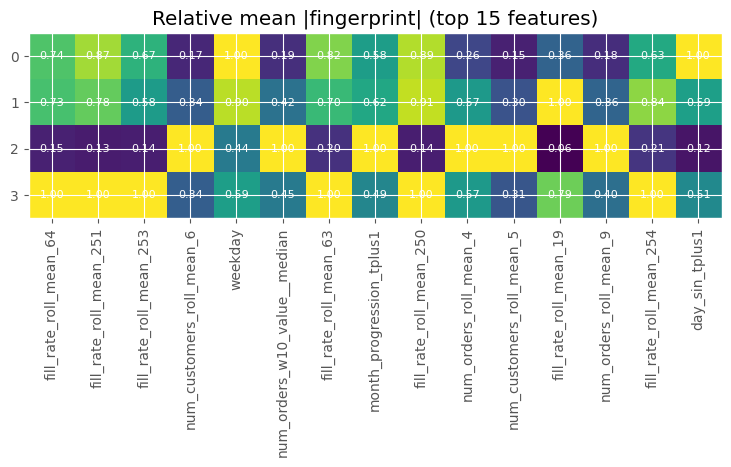

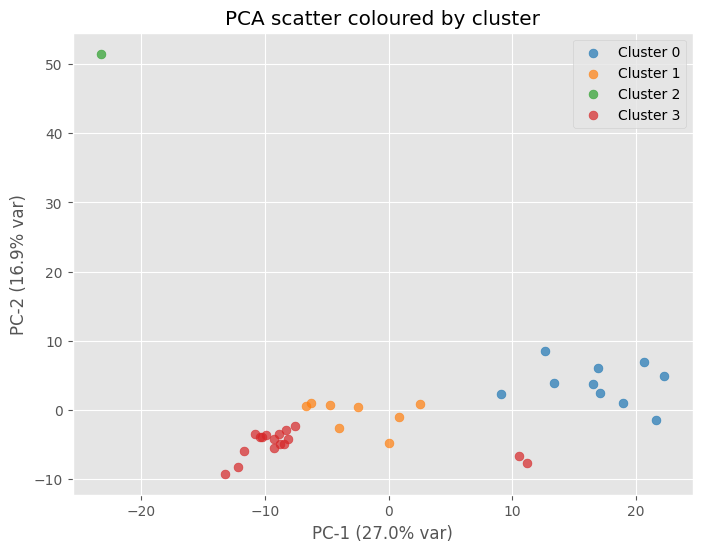


=== SILHOUETTE SUMMARY ===
Global average : 0.14910726708264282


,count,mean,std,min,25%,50%,75%,max
cluster_label,,,,,,,,
0,10.000,0.142,0.083,-0.061,0.121,0.163,0.199,0.227
1,8.000,0.115,0.070,0.049,0.055,0.105,0.136,0.233
2,1.000,0.000,NaN,0.000,0.000,0.000,0.000,0.000
3,17.000,0.178,0.073,0.023,0.126,0.215,0.230,0.252


In [ ]:
# ------------------------------------------------------------------
# 0. Imports & display tweaks
# ------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

plt.style.use("ggplot")
pd.options.display.float_format = "{:,.3f}".format

# ------------------------------------------------------------------
# 1. Load the fingerprints-plus-clusters file
# ------------------------------------------------------------------
csv_path = "fingerprints_with_clusters.csv"   # adjust if in a sub-folder
df = pd.read_csv(csv_path)

# 🔧 ---------------------------------------------------------------
#    Tweak here if needed
#    – tell the script which column holds the cluster labels
#    – and (optionally) what to call the coating ID column
# ------------------------------------------------------------------
cluster_col = "cluster_label" 
id_col      = "coating_id"                    

# cat_cols is defined as a list of column names.
meta_cols = [cluster_col, id_col,
             "coating_id",                  
             "biggest_customer_id_by_volume"]
meta_cols += cat_cols

# ------------------------------------------------------------------
# 2. Identify the fingerprint (feature) columns
# ------------------------------------------------------------------
feature_cols = (
    df.select_dtypes("number")            # keep only numeric cols …
      .columns.difference(meta_cols)      # … except the cluster label
      .tolist()
)

# ------------------------------------------------------------------
# 3. Quick cluster-size table
# ------------------------------------------------------------------
print("=== CLUSTER SIZES ===")
size_tbl = df[cluster_col].value_counts().sort_index()
display(size_tbl)

# ------------------------------------------------------------------
# 4. Top-N per-cluster features by mean |value|
# ------------------------------------------------------------------
TOP_N = 8

top_feats = (
    df.groupby(cluster_col)[feature_cols]
      .apply(lambda g: g.abs().mean().sort_values(ascending=False).head(TOP_N))
      .unstack(level=0)
)

print(f"\n=== TOP-{TOP_N} DRIVING FEATURES PER CLUSTER ===")
display(top_feats)

# ------------------------------------------------------------------
# 5. Heat-map of mean |fingerprint| (top-M overall discriminators)
# ------------------------------------------------------------------
M = 15                                            # number of features to plot
overall_means = df[feature_cols].abs().mean()
hot_feats = overall_means.sort_values(ascending=False).head(M).index

heat = (
    df.groupby(cluster_col)[hot_feats]
      .mean()
      .apply(lambda col: col / col.max(), axis=0)   # 0-1 within each column
)

fig, ax = plt.subplots(figsize=(1.8*M, 0.6*len(heat)))
im = ax.imshow(heat, cmap="viridis")

ax.set_xticks(range(M))
ax.set_xticklabels(hot_feats, rotation=90)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

for i in range(len(heat.index)):
    for j in range(M):
        ax.text(j, i, f"{heat.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8, color="white")

ax.set_title(f"Relative mean |fingerprint| (top {M} features)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6. 2-D PCA scatter for visual overlap check
# ------------------------------------------------------------------
X = df[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42).fit(X_scaled)
X2d = pca.transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
clusters = df[cluster_col].values
uniq = np.unique(clusters)
colors = cm.tab10.colors

for i, lbl in enumerate(uniq):
    sel = clusters == lbl
    ax.scatter(X2d[sel, 0], X2d[sel, 1],
               label=f"Cluster {lbl}",
               s=40, alpha=.7, color=colors[i % len(colors)])

ax.set_xlabel(f"PC-1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC-2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA scatter coloured by cluster")
ax.legend()
plt.show()

# ------------------------------------------------------------------
# 7. Silhouette profile
# ------------------------------------------------------------------
sil_vals = silhouette_samples(X_scaled, clusters, metric="euclidean")
df["silhouette"] = sil_vals

print("\n=== SILHOUETTE SUMMARY ===")
print("Global average :", silhouette_score(X_scaled, clusters))
display(
    df.groupby(cluster_col)["silhouette"].describe().round(3)
)
